# Posterior graph

In [1]:

import os
os.environ["OMP_NUM_THREADS"] = "1"     # agama
os.environ["MKL_NUM_THREADS"] = "1"     # numpy, scipy
os.environ["OPENBLAS_NUM_THREADS"] = "1"    # numpy
os.environ["NUMEXPR_NUM_THREADS"] = "1"     # pandas

import torch 
import numpy as np
from scipy import integrate
import matplotlib.pyplot as plt
from galaxy_generation import transform_params
from object_handler import load_csv

In [2]:
def density(x: np.ndarray, 
            theta: torch.Tensor,
            truth:bool = False) -> np.ndarray:
    """
    Calculate density using GNFW profile as a function of r. Returns the quantiles of the function
    
    Params:
    - x: the value at which the function must be computed at (log_r_div_rstar)
    - theta: MCMC samples of the posterior
    - truth: if True, return without quantiles
    """
    theta = np.array(transform_params(theta))
    
    alpha = theta[:,0]
    beta = theta[:,1]
    gamma = theta[:,2]
    p_0 = theta[:,3]
    r_s = theta[:,4]
    
    out = np.zeros((theta.shape[0], x.shape[0]))
    r_array = 10 ** x
    for i, r in enumerate(r_array):
        out[:,i] = p_0 * (r / r_s) ** -gamma * (1 + (r / r_s) ** alpha) ** (-(beta-gamma)/alpha)
    
    if not truth:
        return np.quantile(np.log10(out), [0.025, 0.16, 0.50, 0.84, 0.975], axis=0).T
    else:
        return np.log10(out)

In [3]:
def density_single(r:float,
                   theta:torch.Tensor) -> np.ndarray:
    """
    Calculate density using GNFW profile as a function of r
    
    Parameters:
    - r: the value at which the function must be computed at
    - theta: an MCMC sample of the posterior
    
    Preconditions:
    - theta.shape == (8,)
    """
    # theta = np.array(transform_params([theta]))

    alpha = theta[0]
    beta = theta[1]
    gamma = theta[2]
    p_0 = theta[3]
    r_s = theta[4]
    
    rho = p_0 * (r / r_s) ** -gamma * (1 + (r / r_s) ** alpha) ** (-(beta-gamma)/alpha)
    
    return rho

def mass(x: np.ndarray, 
         samples: torch.Tensor,
         truth: bool = False) -> np.ndarray:
    """
    Computes the mass for samples at each point of x
    
    Params:
    - x: linspace of the x-values that must be computed
    - samples: MCMC samples of the posterior
    - truth: if True, return without quantiles
    """
    samples = np.array(transform_params(samples))
        
    out = np.zeros((samples.shape[0], x.shape[0]))
    r = 10 ** x
    for i, row in enumerate(samples):
        y = 4 * np.pi * r * r * density_single(r, row)
        
        M_0 = integrate.quad(lambda t: 4 * np.pi * t * t * density_single(t, row), 0, r[0])[0]
        I = integrate.cumulative_trapezoid(y, r) + M_0
        out[i,0] = M_0
        out[i,1:] = I
    
    if not truth:
        return np.quantile(np.log10(out), [0.025, 0.16, 0.50, 0.84, 0.975], axis=0).T
    else:
        return np.log10(out)

In [4]:

def betaCOM(x: float, 
            theta: torch.Tensor,
            truth: bool = False) -> np.ndarray:
    """
    Calculate betaCOM, Cuddeford-Osipkov- Merritt (COM) profile, as a function of r
    
    Params:
    - log_r_div_rstar: the value at which the function must be computed at
    - theta: MCMC samples of the posterior
    - truth: if True, return without quantiles
    """
    theta = np.array(transform_params(theta))
    
    r_a = theta[:,6]
    beta_0 = theta[:,7]
    
    out = np.zeros((theta.shape[0], x.shape[0]))
    
    r_array = 10 ** x
    for i, r in enumerate(r_array):
        out[:,i] = (beta_0 + (r/r_a) ** 2 )/(1 + (r/r_a) ** 2)
    
    if not truth:
        return np.quantile(out, [0.025, 0.16, 0.50, 0.84, 0.975], axis=0).T
    else:
        return out

In [5]:
def prep_truth(x:np.ndarray, 
               theta: list[float]) -> tuple[np.ndarray]:
    """
    Prepare the true function
    
    Params: 
    - x: linspace of the x-values that must be computed
    - theta: true parameters of the equation
    """
    true_density = density(x, torch.tensor([theta]), truth=True).squeeze()
    true_mass = mass(x, torch.tensor([theta]), truth=True).squeeze()
    true_beta = betaCOM(x, torch.tensor([theta]), truth=True).squeeze()
    return true_density, true_mass, true_beta

In [6]:
def plot_line(ax, x, y, truth, iloc):
    """
    plot the line graph
    
    params:
    - ax: the axis to plot on
    - x: x values
    - y: y values, must be in quantiles, y.shape == (n,5)
    - truth: truth values to plot, truth.shape == (n,)
    - iloc: location to plot, in indices
    """
    row, col = iloc
    #2.5-97.5
    ax[row, col].fill_between(x, y[:,0], y[:,4], color=(133/255, 133/255, 247/255, 0.5), label="Mid 95%")

    #16-84
    ax[row, col].fill_between(x, y[:,1], y[:,3], color=(133/255, 133/255, 247/255, 0.8), label="Mid 68%")

    # Median
    ax[row, col].plot(x, y[:,2], color=(8/255, 2/255, 134/255), label="Median")

    # Truth
    ax[row, col].plot(x, truth, color="red", linestyle = "--", label="Truth")
    
    ax[row, col].grid(True)
    ax[row, col].minorticks_on()
    
    return ax
    

In [7]:
def initialize_plot(n_rows=3):
    plt.rcParams["text.usetex"] = True
    fig, axs = plt.subplots(n_rows, 2, 
                            figsize=(8, 4 * n_rows),
                            sharex="col", 
                            sharey="row",
                            gridspec_kw={'hspace': 0,
                                            'wspace': 0,})

    xlim = 2
    resolution = 1000
    x = np.linspace(-xlim, xlim, resolution) # log_r_div_r_star
    
    return fig, axs, x

In [8]:

def plot_aesthetics(ax, fig):
    # Aesthetics
    
    # Core density
    ax[0,0].set_ylabel(r"$\log_{10} \rho (r) \ [M_\odot / \mathrm{kpc}^3]$")
    ax[0,0].xaxis.set_label_position('top')
    ax[0,0].set_xlabel(r"Cored Profile: $\gamma = 0$", fontweight="bold")
    
    # core mass
    ax[1,0].set_ylabel(r"$\log_{10} M(r) / M_\odot$")
    
    # Core beta
    ax[2,0].set_xlabel(r"$\log _{10} (r)$")
    ax[2,0].set_ylabel(r"$\beta ^\mathrm{COM} (r)$")
    
    # Cusp density
    ax[0,1].xaxis.set_label_position('top')
    ax[0,1].set_xlabel(r"Cuspy Profile: $\gamma = 1$", fontweight="bold")
    ax[0,1].legend()
    
    # Cusp mass 
    
    # Cusp beta
    ax[2,1].set_xlabel(r"$\log _{10} (r)$")
    
    title_text = (
            r"Recovered Density and Mass Profile of a Sample Galaxy (Model 1)"
            "\n"
            r"$\alpha = 1,\ \beta = 3,\ \log_{10}(\rho _0)=8.0755,\ \log_{10}(r_s) = 0,\ \log_{10}(r_* / r_s) = -0.6402,\ \log_{10} (r_a / r_*),\ \beta_0 = 0$"
        )
    fig.suptitle(title_text, y=0.98)

    fig.tight_layout()
    
    return ax, fig

## With Mass

[-2.         -1.995996   -1.99199199 -1.98798799 -1.98398398 -1.97997998
 -1.97597598 -1.97197197 -1.96796797 -1.96396396 -1.95995996 -1.95595596
 -1.95195195 -1.94794795 -1.94394394 -1.93993994 -1.93593594 -1.93193193
 -1.92792793 -1.92392392 -1.91991992 -1.91591592 -1.91191191 -1.90790791
 -1.9039039  -1.8998999  -1.8958959  -1.89189189 -1.88788789 -1.88388388
 -1.87987988 -1.87587588 -1.87187187 -1.86786787 -1.86386386 -1.85985986
 -1.85585586 -1.85185185 -1.84784785 -1.84384384 -1.83983984 -1.83583584
 -1.83183183 -1.82782783 -1.82382382 -1.81981982 -1.81581582 -1.81181181
 -1.80780781 -1.8038038  -1.7997998  -1.7957958  -1.79179179 -1.78778779
 -1.78378378 -1.77977978 -1.77577578 -1.77177177 -1.76776777 -1.76376376
 -1.75975976 -1.75575576 -1.75175175 -1.74774775 -1.74374374 -1.73973974
 -1.73573574 -1.73173173 -1.72772773 -1.72372372 -1.71971972 -1.71571572
 -1.71171171 -1.70770771 -1.7037037  -1.6996997  -1.6956957  -1.69169169
 -1.68768769 -1.68368368 -1.67967968 -1.67567568 -1

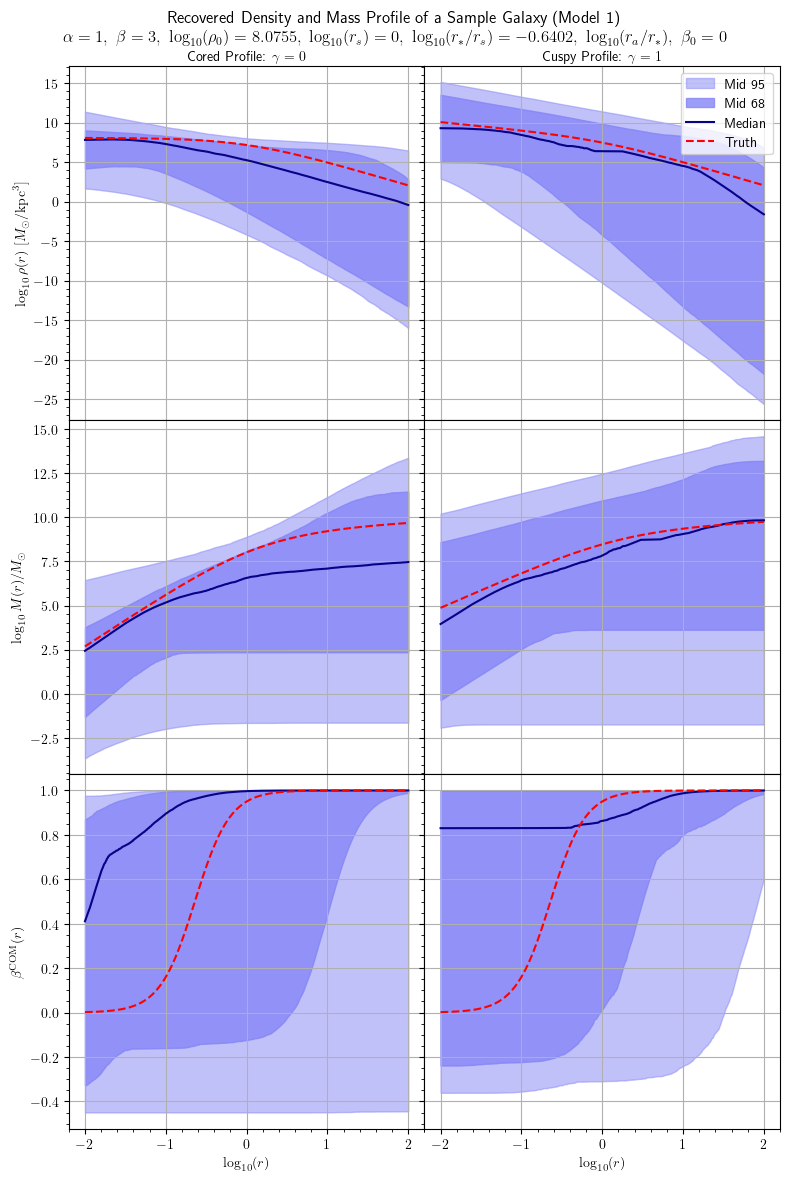

In [ ]:
core_params = load_csv("./model_1/mass_density_samples_core.csv", "Tensor")
cusp_params = load_csv("./model_1/mass_density_samples_cusp.csv", "Tensor")

fig, ax, x = initialize_plot()
core_density = density(x, core_params)
core_mass = mass(x, core_params)
core_beta = betaCOM(x, core_params)


cusp_density = density(x, cusp_params)
cusp_mass = mass(x, cusp_params)
cusp_beta = betaCOM(x, cusp_params)

true_cusp_density, true_cusp_mass, true_cusp_beta = prep_truth(x, [1, 3, 1, 8.0755, 0, -0.6402, 0, 0])
true_core_density, true_core_mass, true_core_beta = prep_truth(x, [1, 3, 0, 8.0755, 0, -0.6402, 0, 0])

ax = plot_line(ax, x, core_density, true_core_density,[0,0])
ax = plot_line(ax, x, core_mass,    true_core_mass,   [1,0])
ax = plot_line(ax, x, core_beta,    true_core_beta,   [2,0])
ax = plot_line(ax, x, cusp_density, true_cusp_density,[0,1])
ax = plot_line(ax, x, cusp_mass,    true_cusp_mass,   [1,1])
ax = plot_line(ax, x, cusp_beta,    true_cusp_beta,   [2,1])

ax, fig = plot_aesthetics(ax, fig)

plt.show()

## No Mass

In [9]:

def plot_aesthetics(ax, fig):
    # Aesthetics
    
    # Core density
    ax[0,0].set_ylabel(r"$\log_{10} \rho (r) \ [M_\odot / \mathrm{kpc}^3]$")
    ax[0,0].xaxis.set_label_position('top')
    ax[0,0].set_xlabel(r"Cored Profile: $\gamma = 0$", fontweight="bold")
    
    # # core mass
    # ax[1,0].set_ylabel(r"$\log_{10} M(r) / M_\odot$")
    
    # Core beta
    ax[1,0].set_xlabel(r"$\log _{10} (r)$")
    ax[1,0].set_ylabel(r"$\beta ^\mathrm{COM} (r)$")
    
    # Cusp density
    ax[0,1].xaxis.set_label_position('top')
    ax[0,1].set_xlabel(r"Cuspy Profile: $\gamma = 1$", fontweight="bold")
    ax[0,1].legend()
    
    # Cusp mass 
    
    # Cusp beta
    ax[1,1].set_xlabel(r"$\log _{10} (r)$")
    
    title_text = (
            r"Recovered Density and Mass Profile of a Sample Galaxy (Model 2)"
            "\n"
            r"$\alpha = 1,\ \beta = 3,\ \log_{10}(\rho _0)=8.0755,\ \log_{10}(r_s) = 0,\ \log_{10}(r_* / r_s) = -0.6402,\ \log_{10} (r_a / r_*),\ \beta_0 = 0$"
        )
    fig.suptitle(title_text, y=0.98)

    fig.tight_layout()
    
    return ax, fig

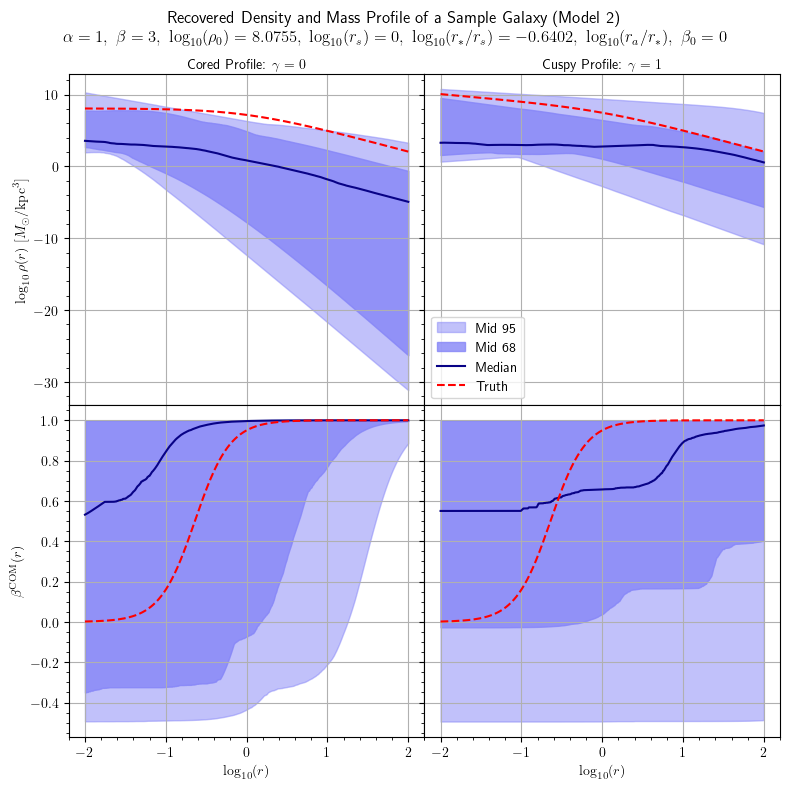

In [10]:
core_params = load_csv("./model_2/mass_density_samples_core.csv", "Tensor")
cusp_params = load_csv("./model_2/mass_density_samples_cusp.csv", "Tensor")

fig, ax, x = initialize_plot(n_rows=2)
core_density = density(x, core_params)
# core_mass = mass(x, core_params)
core_beta = betaCOM(x, core_params)


cusp_density = density(x, cusp_params)
# cusp_mass = mass(x, cusp_params)
cusp_beta = betaCOM(x, cusp_params)

true_cusp_density, true_cusp_mass, true_cusp_beta = prep_truth(x, [1, 3, 1, 8.0755, 0, -0.6402, 0, 0])
true_core_density, true_core_mass, true_core_beta = prep_truth(x, [1, 3, 0, 8.0755, 0, -0.6402, 0, 0])

ax = plot_line(ax, x, core_density, true_core_density,[0,0])
# ax = plot_line(ax, x, core_mass,    true_core_mass,   [1,0])
ax = plot_line(ax, x, core_beta,    true_core_beta,   [1,0])
ax = plot_line(ax, x, cusp_density, true_cusp_density,[0,1])
# ax = plot_line(ax, x, cusp_mass,    true_cusp_mass,   [1,1])
ax = plot_line(ax, x, cusp_beta,    true_cusp_beta,   [1,1])

ax, fig = plot_aesthetics(ax, fig)

plt.show()